In [250]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


def thimble_plot(action=None, drift=None, crit_points=None, flow_equation=None, 
                sigma_abs=1, sigma_phase=np.pi/4,lamb_abs=1, lamb_phase=0,
                epsilon = 0.001, t_span = (0, 10),t_points=10000, 
                x_range = (-3, 3), y_range = (-3, 3), z0 = 1, r=1
                ):
    
    import numpy as np
    sigma = sigma_abs*np.exp(1j*sigma_phase)
    lamb = lamb_abs*np.exp(1j*lamb_phase)

    if action==None:
        def action(z, sigma, lamb):
            """Action S(z) = 1/2 * sigma * z^2 + lamb / 4 * z^4"""

            return 1/2 * sigma * z**2 + lamb / 4 * z**4
    if drift==None:
        def drift(z, sigma,lamb):
            """Derivative of the action with respect to z."""
            return sigma * z + lamb * z**3
        
    if crit_points==None:
        cp0 = -np.sqrt(-sigma / lamb)
        cp1 = 0
        cp2 = +np.sqrt(-sigma / lamb)
        crit_points = np.array([cp0, cp1, cp2])
        crit_points = np.array([0])

    if flow_equation==None:
        def flow_equation(t, z, sigma, lamb, factor):
            """The flow equation dz/dt = conjugate(S'(z))"""
            dz_dt = factor*np.conj(drift(z, sigma, lamb))
            return dz_dt
        
    t_eval = np.linspace(t_span[0], t_span[1], t_points)

    # Loop through each sigma value and corresponding subplot
    fig, ax = plt.subplots(1, figsize=(7, 7), sharex= True, sharey = True)
    fig.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing between subplots
        
        # Plot the flow of Lefschetz Thimbles
    for cp in crit_points:
        for idx, perturb in enumerate(epsilon*np.exp(1j*np.linspace(0, 2*np.pi, 8, endpoint=False))):
            print(idx)
            cp_0 = cp + perturb
            factor = +1
            solution = solve_ivp(flow_equation, t_span, [cp_0], args=(r, sigma, lamb, factor), t_eval=t_eval, method="RK45")
            z_values = solution.y[0]
            ax.plot(z_values.real, z_values.imag, color='black')

            factor = -1
            solution = solve_ivp(flow_equation, t_span, [cp_0], args=(r, sigma, lamb, factor), t_eval=t_eval, method="RK45")
            z_values = solution.y[0]
            ax.plot(z_values.real, z_values.imag, color='black', ls='--')
        
    # Scatter plot the critical points
    ax.scatter(crit_points.real, crit_points.imag, color='red', zorder=5, label="critical points")
    
    # Create the vector field of the action
    x = np.linspace(*x_range, 35)
    y = np.linspace(*y_range, 35)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    drift_values = -1*drift(Z, z0=z0, r=r, sigma=sigma, lamb=lamb)

    U = np.real(drift_values)
    V = np.imag(drift_values)
    mags = np.abs(drift_values)
    # threshold = 1e-1
    # mags[mags<threshold] = np.inf

    ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=45, alpha=0.9)

    # Add background heatmap for drift values
    x = np.linspace(*x_range, 400)
    y = np.linspace(*y_range, 400)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    drift_values = drift(Z, z0=z0, r=r, sigma=sigma, lamb=lamb)
    mags = np.abs(drift_values)
    threshold = 1e-1
    mags[mags < threshold] = 0

    ax.imshow(-np.log10(mags), extent=[*x_range, *y_range], origin='lower', cmap='hot', alpha=0.7)

    # Set plot details for each subplot
    fig.suptitle(f'σ = {np.round(sigma, decimals=2)}', fontsize=14)
    ax.set_xlabel('Re(z)', fontsize=12)
    ax.set_ylabel('Im(z)', fontsize=12)
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    ax.axvline(0, color="black", linewidth=0.5, linestyle="--")
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)# S_derivative_real
    ax.set_aspect('equal', adjustable='box')

    ax.set_xlim(*(val * 1.0001 for val in x_range))
    ax.set_ylim(*(val * 1.0001 for val in y_range))

    from matplotlib.lines import Line2D

    handles, labels = plt.gca().get_legend_handles_labels()

    line_stable = Line2D([0], [0], label=r'$\mathcal{J}$', ls='-', color='black')
    line_unstable = Line2D([0], [0], label=r'$\mathcal{K}$', ls = '--', color='black')

    # add manual symbols to auto legend
    handles.extend([line_unstable, line_stable])

    ax.legend(handles=handles, bbox_to_anchor=(0, 1.01, 1, 0.2), fontsize = 10, loc="lower left",mode="expand", borderaxespad=0, ncol=4, handletextpad=0.5)
    fig.subplots_adjust(top=0.9, bottom=0.1, left=0.05, right=0.9, hspace=0.0, wspace=0.0)

We want to artificially introduce zeros in the density by a additive modification of the action. 
$$
S \to \tilde{S} = \frac{\sigma}{2}z^2+\frac{\lambda}{4}z^4+\psi(z)\qquad \rho \to \tilde{\rho} = \rho + R(z)
$$
forcing $\tilde{\rho} = \tilde{S}$ gives
$$
\psi(z) = -\ln(1+R(z)e^{S})
$$

As an example, we want to generate a zero in $\tilde{\rho}$ at a finite $z = z_{0}$. 
This is achieved by setting $R(z) = -\rho(z_{0})$ resulting in 
$$
\psi(z) = -\ln\left( 1-\exp\left( \frac{\sigma}{2}(z^2-z_{0}^2)+\frac{\lambda}{4}(z^4-z_{0}^4) \right) \right)
$$
The drift is calculated
$$
\partial_{z}\tilde{S} = \partial_{z}S+\partial_{z}\psi= \partial_{z}S+\frac{\exp\left( \frac{\sigma}{2}(z^2-z_{0}^2)+\frac{\lambda}{4}(z^4-z_{0}^4) \right)}{1-\exp\left( \frac{\sigma}{2}(z^2-z_{0}^2)+\frac{\lambda}{4}(z^4-z_{0}^4) \right)}\partial_{z}S= \partial_{z}S\, \left[ 1+\frac{\exp{\{S(z)-S(z_{0})\}}}{1-\exp{\{S(z)-S(z_{0})\}}} \right]
$$
Further simplifying
$$
\partial_{z}\tilde{S} = \partial_{z}S \, \left[ \frac{1}{1-\exp{\{S(z)-S(z_{0})\}}} \right]
$$

In [251]:
from sympy import symbols, diff, Function, re, im, sqrt, exp, I
import sympy as sp
r, z, z_0 = symbols('r z z_0', real=True)
sigma, lamb = symbols('sigma lambda')

action = sigma/2*z**2 + lamb/4*z**4
action_z_0 = sigma/2*z_0**2 + lamb/4*z_0**4

R = -exp(-action_z_0)
action_mod = action-sp.log(1+R*exp(action))

drift_mod = sp.diff(action_mod, z).simplify()
density_mod = exp(-action_mod)

curv_mod = sp.diff(drift_mod, z).simplify()
curv_mod_func  = sp.lambdify((symbols('z z_0 sigma lambda r')), curv_mod,  'numpy')
drift_mod

z*(lambda*z**2 + sigma)*exp(z_0**2*(lambda*z_0**2/2 + sigma))/(exp(z_0**2*(lambda*z_0**2/2 + sigma)) - exp(lambda*z**4/4 + lambda*z_0**4/4 + sigma*z**2/2 + sigma*z_0**2/2))

In [252]:
def action_mod_func(z, z0, r, sigma, lamb):
    action = lamb * z**4 / 4 + sigma * z**2 / 2
    action_z_0 = sigma/2*z0**2+lamb/4*z0**4
    out = action

    delta_s = action-action_z_0
    overflow = np.real(delta_s)>20
    if overflow:
        out -= 1j*np.pi + delta_s
    else:
        out -= np.log(1-np.exp(delta_s))
    return out

action_mod_func = np.vectorize(action_mod_func)

In [253]:
def drift_mod_func(z, z0, r, sigma, lamb):
    drift = lamb * z**3 + sigma * z
    action = lamb * z**4 / 4 + sigma * z**2 / 2
    action_z_0 = sigma/2*z0**2+lamb/4*z0**4

    delta_s = action-action_z_0
    overflow = np.real(delta_s)>20
    if delta_s == 0: return np.inf
    if overflow:
        out = -drift*np.exp(-delta_s)
    else:
        out = drift / (1-np.exp(delta_s))
    return out

drift_mod_func = np.vectorize(drift_mod_func)


0
1
2
3
4
5
6
7


/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_31248/2716547361.py:76: RuntimeWarning: invalid value encountered in divide
  ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=45, alpha=0.9)
/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_31248/2716547361.py:88: RuntimeWarning: divide by zero encountered in log10
  ax.imshow(-np.log10(mags), extent=[*x_range, *y_range], origin='lower', cmap='hot', alpha=0.7)


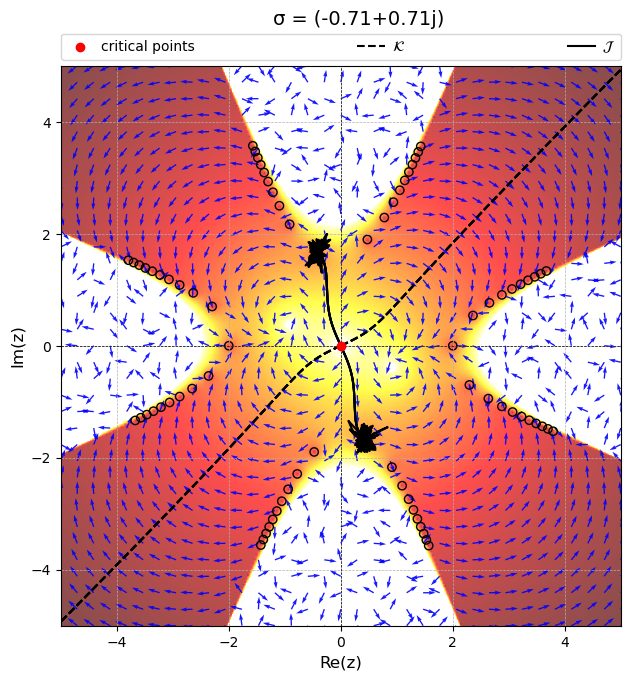

In [254]:
z0 = 2

def flow_equation(t, z, r, sigma, lamb, factor):
    drift =  drift_mod_func(z, z0, r, sigma, lamb)
    return factor*np.conj(drift)


sigma_phase=3*np.pi/4
lamb_phase=0
sigma_abs=1
lamb_abs=1
sigma = sigma_abs*np.exp(1j*sigma_phase)
lamb = lamb_abs*np.exp(1j*lamb_phase)
x_range = (-5, 5)
y_range = (-5, 5)
thimble_plot(action=action_mod_func, drift=drift_mod_func, flow_equation=flow_equation, z0 = z0, sigma_phase=sigma_phase, t_span=(0,10), x_range=x_range, y_range=y_range)

action_z_0 = sigma/2*z0**2 + lamb/4*z0**4
for k in range(-10, 10):
    c_k = (sigma / 2) * z0**2 + (lamb / 4) * z0**4 + 2 * np.pi * 1j * k

    u_plus = (-sigma + np.sqrt(sigma**2 + 4 * lamb * c_k)) / lamb
    u_minus = (-sigma - np.sqrt(sigma**2 + 4 * lamb * c_k)) / lamb

    z_plus_plus = np.sqrt(u_plus)
    z_plus_minus = -np.sqrt(u_plus)
    z_minus_plus = np.sqrt(u_minus)
    z_minus_minus = -np.sqrt(u_minus)

    z_solutions = np.array([z_plus_plus, z_plus_minus, z_minus_plus, z_minus_minus])
    plt.scatter(z_solutions.real, z_solutions.imag, color = 'black', facecolors='none', edgecolors='black')

Let's look at the modification 
$$
R(z) = r(z^2-z_0^2)-\rho(-S_0)
$$

In [255]:
from sympy import symbols, diff, Function, re, im, sqrt, exp
import sympy as sp
sigma_r, lamb_r = symbols('sigma_r, lambda_r', real=True)
sigma_phi, lamb_phi = symbols('sigma_phi, lambda_phi', real=True)
sigma, lamb = sigma_r*exp(sp.I*sigma_phi), lamb_r*exp(sp.I*lamb_phi)
z_phi, z_r = symbols('z_phi, z_r', real=True)
z = z_r*exp(sp.I*z_phi)
z = symbols('z')
# sigma, lamb = symbols('sigma lambda')
action = sigma/2*z**2 + lamb/4*z**4

In [256]:
r, z, z_0 = symbols('r z z_0', real=True)
sigma, lamb = symbols('sigma lambda')

action = sigma/2*z**2 + lamb/4*z**4
action_z_0 = sigma/2*z_0**2 + lamb/4*z_0**4

R = r*(z**2-z_0**2)-exp(-action_z_0)
action_mod = action-sp.log(1+R*exp(action))
action_mod_func = sp.lambdify((z, z_0, sigma, lamb, r), action_mod, 'numpy')

drift_mod = sp.diff(action_mod, z).simplify()
drift_mod_func  = sp.lambdify((symbols('t z z_0 sigma lambda r')), drift_mod,  'numpy')
density_mod = exp(-action_mod)

curv_mod = sp.diff(drift_mod, z).simplify()
curv_mod_func  = sp.lambdify((symbols('z z_0 sigma lambda r')), curv_mod,  'numpy')
drift_mod

z*(lambda*z**2 - 2*r*exp(lambda*z**4/4 + sigma*z**2/2) + sigma)*exp(lambda*z_0**4/4 + sigma*z_0**2/2)/(r*z**2*exp(lambda*z**4/4 + lambda*z_0**4/4 + sigma*z**2/2 + sigma*z_0**2/2) - r*z_0**2*exp(lambda*z**4/4 + lambda*z_0**4/4 + sigma*z**2/2 + sigma*z_0**2/2) - exp(lambda*z**4/4 + sigma*z**2/2) + exp(lambda*z_0**4/4 + sigma*z_0**2/2))

In [257]:
def drift_mod_func(z, z0, r, sigma, lamb):
    action = lamb * z**4 / 4 + sigma * z**2 / 2
    action_z_0 = sigma/2*z0**2+lamb/4*z0**4
    drift = sigma*z+lamb*z**3

    # case of action -> -inf
    threshold_log = 10
    if -np.real(action) > threshold_log + np.log(np.abs((2*r*z) / (drift))):
        out = drift*(1-np.exp(action-action_z_0))
    else:
        num = drift*np.exp(-action)-2*r*z
        den = r*(z**2-z0**2) - np.exp(-action_z_0)+ np.exp(-action)
        out = num/den
    # num = drift*np.exp(-action)-2*r*z
    # den = r*(z**2-z0**2) - np.exp(-action_z_0)+ np.exp(-action)
    # out = num/den
    return out

drift_mod_func = np.vectorize(drift_mod_func)

0
1
2
3
4
5
6
7


/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_31248/44977733.py:8: RuntimeWarning: invalid value encountered in scalar divide
  if -np.real(action) > threshold_log + np.log(np.abs((2*r*z) / (drift))):
/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_31248/2716547361.py:76: RuntimeWarning: invalid value encountered in divide
  ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=45, alpha=0.9)
/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_31248/2716547361.py:88: RuntimeWarning: divide by zero encountered in log10
  ax.imshow(-np.log10(mags), extent=[*x_range, *y_range], origin='lower', cmap='hot', alpha=0.7)


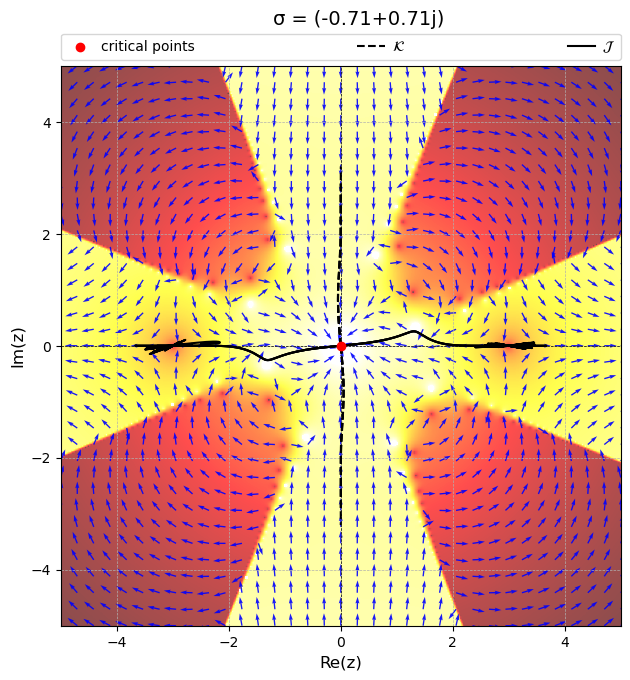

In [258]:
z0 = 3

def flow_equation(t, z, r, sigma, lamb, factor):
    drift =  drift_mod_func(z, z0, r, sigma, lamb)
    return factor*np.conj(drift)


sigma_phase=3*np.pi/4
lamb_phase=0
sigma_abs=1
lamb_abs=1
sigma = sigma_abs*np.exp(1j*sigma_phase)
lamb = lamb_abs*np.exp(1j*lamb_phase)
x_range = (-5, 5)
y_range = (-5, 5)
thimble_plot(drift=drift_mod_func, flow_equation=flow_equation, z0 = z0, sigma_phase=sigma_phase, t_span=(0,30), x_range=x_range, y_range=y_range, r=1.5)


0
1
2
3
4
5
6
7


/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_31248/44977733.py:8: RuntimeWarning: invalid value encountered in scalar divide
  if -np.real(action) > threshold_log + np.log(np.abs((2*r*z) / (drift))):
/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_31248/2716547361.py:76: RuntimeWarning: invalid value encountered in divide
  ax.quiver(X, Y, U/mags, V/mags, color="blue", angles="xy", scale=45, alpha=0.9)
/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_31248/2716547361.py:88: RuntimeWarning: divide by zero encountered in log10
  ax.imshow(-np.log10(mags), extent=[*x_range, *y_range], origin='lower', cmap='hot', alpha=0.7)


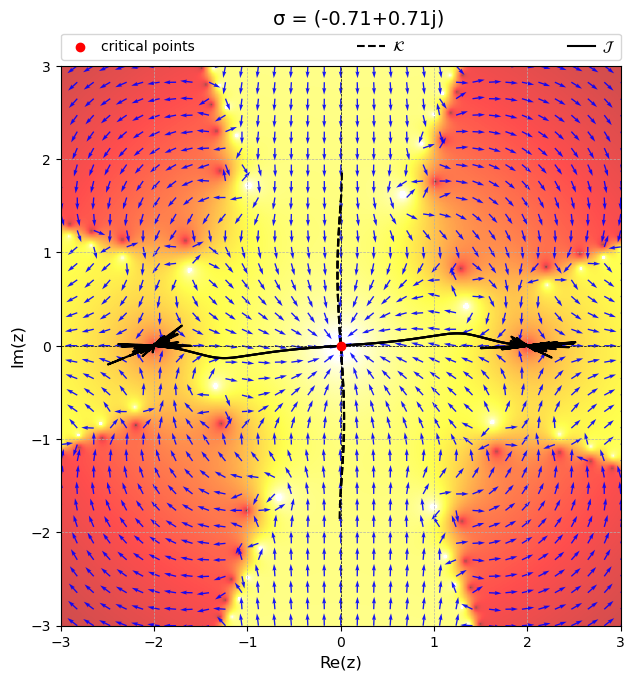

In [295]:
z0 = 2

def flow_equation(t, z, r, sigma, lamb, factor):
    drift =  drift_mod_func(z, z0, r, sigma, lamb)
    return factor*np.conj(drift)


sigma_phase=3/4*np.pi
lamb_phase=0
sigma_abs=1
lamb_abs=1
sigma = sigma_abs*np.exp(1j*sigma_phase)
lamb = lamb_abs*np.exp(1j*lamb_phase)
x_range = (-3, 3)
y_range = (-3, 3)
thimble_plot(drift=drift_mod_func, flow_equation=flow_equation, z0 = z0, sigma_phase=sigma_phase, t_span=(0,12), x_range=x_range, y_range=y_range, r=2)
